# Tutorial 5 - Polynomial Interpolation

---

## 1. The Interpolation Problem

Given $n+1$ data points $(x_0, y_0), (x_1, y_1), \ldots, (x_n, y_n)$ with **distinct** nodes $x_i$, we want to find a polynomial $p(x)$ of degree at most $n$ such that:

$$p(x_i) = y_i, \quad i = 0, 1, \ldots, n$$

**Key theorem (Uniqueness):** There is exactly one polynomial of degree $\leq n$ that passes through $n+1$ distinct data points.

### Why interpolation?
- Reconstruct a function from measurements (seismic traces, temperature records, geophysical surveys)
- Evaluate a function at points between known data
- Build quadrature rules (Gaussian quadrature uses interpolation)
- Basis for finite element shape functions

In [1]:
import sys, math
sys.path.insert(0, '../')   # adjust if running from tutorials/
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

from numethods.interpolation import NewtonInterpolation, LagrangeInterpolation

print("numethods interpolation module loaded.")

numethods interpolation module loaded.


## 2. Lagrange Interpolation

The **Lagrange form** builds the interpolating polynomial as:

$$p(x) = \sum_{i=0}^{n} y_i \, L_i(x)$$

where each **Lagrange basis polynomial** is:

$$L_i(x) = \prod_{\substack{j=0 \\ j \neq i}}^{n} \frac{x - x_j}{x_i - x_j}$$

### Properties
- $L_i(x_j) = \delta_{ij}$ (1 if $i=j$, 0 otherwise)
- Each $L_i$ has degree exactly $n$
- **Cost:** $O(n^2)$ per evaluation — not efficient for large $n$

### Example: Linear interpolation (n=1)
Two points $(x_0, y_0)$ and $(x_1, y_1)$:

$$L_0(x) = \frac{x - x_1}{x_0 - x_1}, \quad L_1(x) = \frac{x - x_0}{x_1 - x_0}$$

$$p(x) = y_0 \cdot \frac{x - x_1}{x_0 - x_1} + y_1 \cdot \frac{x - x_0}{x_1 - x_0}$$

In [2]:
# Simple 3-point Lagrange example
x_data = [0.0, 1.0, 2.0]
y_data = [1.0, 3.0, 2.0]

lagr = LagrangeInterpolation(x_data, y_data)

# Evaluate at several points
test_pts = [0.0, 0.5, 1.0, 1.5, 2.0]
print("Lagrange Interpolation: x^2 - 2x + 1 data (roughly)")
print(f"{'x':>8} | {'p(x)':>10}")
print("-" * 22)
for t in test_pts:
    print(f"{t:8.2f} | {lagr.evaluate(t):10.6f}")

Lagrange Interpolation: x^2 - 2x + 1 data (roughly)
       x |       p(x)
----------------------
    0.00 |   1.000000
    0.50 |   2.375000
    1.00 |   3.000000
    1.50 |   2.875000
    2.00 |   2.000000


## 3. Newton's Divided Difference Form

The **Newton form** builds the polynomial incrementally using **divided differences**, which makes it easy to add new points without restarting.

$$p(x) = c_0 + c_1(x-x_0) + c_2(x-x_0)(x-x_1) + \cdots + c_n(x-x_0)\cdots(x-x_{n-1})$$

### Divided Differences Table

| Order | Symbol | Formula |
|-------|--------|---------|
| 0th | $f[x_i]$ | $y_i$ |
| 1st | $f[x_i, x_{i+1}]$ | $\dfrac{f[x_{i+1}] - f[x_i]}{x_{i+1} - x_i}$ |
| 2nd | $f[x_i, x_{i+1}, x_{i+2}]$ | $\dfrac{f[x_{i+1},x_{i+2}] - f[x_i,x_{i+1}]}{x_{i+2} - x_i}$ |
| $k$th | $f[x_i,\ldots,x_{i+k}]$ | $\dfrac{f[x_{i+1},\ldots,x_{i+k}] - f[x_i,\ldots,x_{i+k-1}]}{x_{i+k} - x_i}$ |

The **coefficients** $c_i = f[x_0, x_1, \ldots, x_i]$ are the diagonal entries of the divided difference table.

### Advantages over Lagrange
- Adding a new data point adds just one new term: $O(n)$ update
- Nested (Horner) evaluation: $O(n)$ per point
- Numerically equivalent but more efficient for incremental data

In [3]:
# Manual divided difference table for transparency
def divided_diff_table(x, y):
    n = len(x)
    F = [[0.0]*n for _ in range(n)]
    for i in range(n):
        F[i][0] = y[i]
    for j in range(1, n):
        for i in range(n - j):
            F[i][j] = (F[i+1][j-1] - F[i][j-1]) / (x[i+j] - x[i])
    return F

x_data = [1.0, 2.0, 4.0, 7.0]
y_data = [3.0, 6.0, 3.0, 9.0]

F = divided_diff_table(x_data, y_data)

print("Divided Difference Table")
print(f"{'x':>6} | {'f[x]':>8} | {'f[.,.]':>10} | {'f[.,.,.] ':>12} | {'f[.,.,.,.]':>14}")
print("-" * 65)
for i in range(len(x_data)):
    row = f"{x_data[i]:6.2f} | {F[i][0]:8.4f}"
    for j in range(1, len(x_data)-i):
        row += f" | {F[i][j]:12.6f}"
    print(row)

print(f"\nNewton coefficients c_i = F[0][i]: {[round(F[0][j],6) for j in range(len(x_data))]}")

Divided Difference Table
     x |     f[x] |     f[.,.] |    f[.,.,.]  |     f[.,.,.,.]
-----------------------------------------------------------------
  1.00 |   3.0000 |     3.000000 |    -1.500000 |     0.366667
  2.00 |   6.0000 |    -1.500000 |     0.700000
  4.00 |   3.0000 |     2.000000
  7.00 |   9.0000

Newton coefficients c_i = F[0][i]: [3.0, 3.0, -1.5, 0.366667]


In [4]:
# Using the numethods Newton interpolation
newt = NewtonInterpolation(x_data, y_data)

print("Newton Interpolation Evaluations")
print(f"{'x':>8} | {'p(x)':>12}")
print("-" * 24)
for t in [1.0, 1.5, 3.0, 4.0, 5.5, 7.0]:
    print(f"{t:8.2f} | {newt.evaluate(t):12.6f}")

Newton Interpolation Evaluations
       x |         p(x)
------------------------
    1.00 |     3.000000
    1.50 |     5.104167
    3.00 |     5.266667
    4.00 |     3.000000
    5.50 |     1.537500
    7.00 |     9.000000


## 4. Comparison: Newton vs Lagrange

Both methods produce the **same polynomial** — they're just different representations. Let's verify this and compare visually.

### When to prefer which?
| Method | Pros | Cons |
|--------|------|------|
| Lagrange | Conceptually simple, symmetric | $O(n^2)$ to add points, all basis polys change |
| Newton | $O(n)$ update when adding points, nested evaluation | Slightly more bookkeeping |

In [5]:
# Verify Newton == Lagrange on same data
x_data = [0.0, 1.0, 3.0, 5.0]
y_data = [2.0, -1.0, 4.0, 1.0]

newt = NewtonInterpolation(x_data, y_data)
lagr = LagrangeInterpolation(x_data, y_data)

test_pts = [i*0.5 for i in range(11)]  # 0 to 5 in steps of 0.5

print("Comparing Newton vs Lagrange:")
print(f"{'x':>6} | {'Newton':>12} | {'Lagrange':>12} | {'Diff':>10}")
print("-" * 50)
max_diff = 0.0
for t in test_pts:
    pn = newt.evaluate(t)
    pl = lagr.evaluate(t)
    diff = abs(pn - pl)
    max_diff = max(max_diff, diff)
    print(f"{t:6.2f} | {pn:12.8f} | {pl:12.8f} | {diff:10.2e}")

print(f"\nMax difference: {max_diff:.2e}  (should be ~machine epsilon)")

Comparing Newton vs Lagrange:
     x |       Newton |     Lagrange |       Diff
--------------------------------------------------
  0.00 |   2.00000000 |   2.00000000 |   0.00e+00
  0.50 |  -0.31250000 |  -0.31250000 |   0.00e+00
  1.00 |  -1.00000000 |  -1.00000000 |   0.00e+00
  1.50 |  -0.48750000 |  -0.48750000 |   1.67e-16
  2.00 |   0.80000000 |   0.80000000 |   2.22e-16
  2.50 |   2.43750000 |   2.43750000 |   4.44e-16
  3.00 |   4.00000000 |   4.00000000 |   4.44e-16
  3.50 |   5.06250000 |   5.06250000 |   1.78e-15
  4.00 |   5.20000000 |   5.20000000 |   8.88e-16
  4.50 |   3.98750000 |   3.98750000 |   8.88e-16
  5.00 |   1.00000000 |   1.00000000 |   8.88e-16

Max difference: 1.78e-15  (should be ~machine epsilon)


## 5. Visualizing Interpolating Polynomials

Let's build an interpolating polynomial for $\sin(x)$ on $[0, 2\pi]$ with increasing node counts and see how accuracy improves.

This illustrates a key property: with equally-spaced nodes, **polynomial interpolation of smooth functions converges as $n \to \infty$** (on bounded intervals without corners).

In [6]:
import math

def true_func(x):
    return math.sin(x)

# Evaluate interpolation at fine grid
def dense_eval(interp_obj, x_min, x_max, N=300):
    xs = [x_min + (x_max - x_min)*i/(N-1) for i in range(N)]
    ys = [interp_obj.evaluate(xi) for xi in xs]
    return xs, ys

x_min, x_max = 0.0, 2*math.pi
x_fine = [x_min + (x_max-x_min)*i/299 for i in range(300)]
y_true = [true_func(xi) for xi in x_fine]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle("Polynomial Interpolation of sin(x) on [0, 2π]", fontsize=13)

for ax, n_pts in zip(axes, [3, 6, 10]):
    # Equally-spaced nodes
    nodes_x = [x_min + (x_max-x_min)*i/(n_pts-1) for i in range(n_pts)]
    nodes_y = [true_func(xi) for xi in nodes_x]
    
    interp = NewtonInterpolation(nodes_x, nodes_y)
    xs_i, ys_i = dense_eval(interp, x_min, x_max)
    
    max_err = max(abs(yi - true_func(xi)) for xi, yi in zip(xs_i, ys_i))
    
    ax.plot(x_fine, y_true, 'k-', linewidth=1.5, label='sin(x)')
    ax.plot(xs_i, ys_i, 'b--', linewidth=1.5, label=f'p_{n_pts-1}(x)')
    ax.scatter(nodes_x, nodes_y, color='red', zorder=5, s=60, label='nodes')
    ax.set_title(f'n={n_pts-1} degree\nmax error = {max_err:.2e}')
    ax.legend(fontsize=8)
    ax.set_xlabel('x')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('y')
plt.tight_layout()
plt.savefig('interpolation_sin.png', dpi=100, bbox_inches='tight')
plt.close()
print("Saved interpolation_sin.png")
print("As n increases: error decreases for smooth functions on bounded domains.")

Saved interpolation_sin.png
As n increases: error decreases for smooth functions on bounded domains.


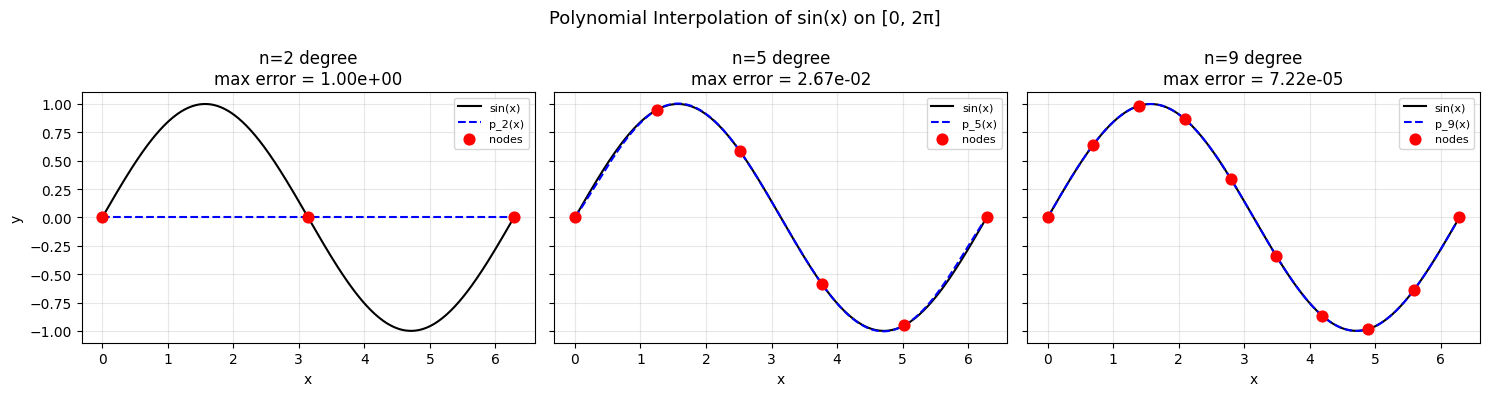

## 6. The Runge Phenomenon

⚠️ **Warning:** For equally-spaced nodes on large intervals, high-degree polynomial interpolation can **diverge** near the endpoints — even for smooth functions!

The classic example is $f(x) = \dfrac{1}{1+25x^2}$ on $[-1, 1]$ (Runge's function).

### Why does this happen?
- The Lebesgue constant $\Lambda_n$ grows rapidly for equally-spaced nodes
- Errors can amplify, especially near endpoints
- Solution: use **Chebyshev nodes** instead of equally-spaced nodes

### Chebyshev Nodes on $[a, b]$

$$x_k = \frac{a+b}{2} + \frac{b-a}{2} \cos\left(\frac{(2k+1)\pi}{2n+2}\right), \quad k = 0, 1, \ldots, n$$

These nodes **cluster near the endpoints** and minimize the maximum interpolation error.

In [7]:
def runge(x):
    return 1.0 / (1 + 25*x**2)

def chebyshev_nodes(a, b, n):
    """n+1 Chebyshev nodes on [a,b]"""
    return [(a+b)/2 + (b-a)/2 * math.cos((2*k+1)*math.pi/(2*n+2))
            for k in range(n+1)]

x_min, x_max = -1.0, 1.0
x_fine = [x_min + (x_max-x_min)*i/499 for i in range(500)]
y_true = [runge(xi) for xi in x_fine]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Runge Phenomenon: Equally-Spaced vs Chebyshev Nodes (n=11)", fontsize=12)

n = 11

for ax, title, use_cheb in zip(axes, 
    ["Equally-Spaced Nodes (Runge phenomenon!)", "Chebyshev Nodes (stable)"],
    [False, True]):
    
    if use_cheb:
        nodes_x = chebyshev_nodes(x_min, x_max, n)
    else:
        nodes_x = [x_min + (x_max-x_min)*i/n for i in range(n+1)]
    
    nodes_y = [runge(xi) for xi in nodes_x]
    
    interp = NewtonInterpolation(sorted(nodes_x), [runge(xi) for xi in sorted(nodes_x)])
    ys_i = [interp.evaluate(xi) for xi in x_fine]
    
    max_err = max(abs(yi - runge(xi)) for xi, yi in zip(x_fine, ys_i))
    
    ax.plot(x_fine, y_true, 'k-', linewidth=2, label='1/(1+25x²)', zorder=3)
    ax.plot(x_fine, ys_i, 'b--', linewidth=1.5, label=f'p_{n}(x)')
    ax.scatter(nodes_x, nodes_y, color='red', zorder=5, s=60, label='nodes')
    ax.set_ylim(-0.5, 1.5)
    ax.set_title(f'{title}\nmax error = {max_err:.3f}')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('x')

plt.tight_layout()
plt.savefig('runge_phenomenon.png', dpi=100, bbox_inches='tight')
plt.close()
print("Saved runge_phenomenon.png")
print("Chebyshev nodes drastically reduce the Runge phenomenon!")

Saved runge_phenomenon.png
Chebyshev nodes drastically reduce the Runge phenomenon!


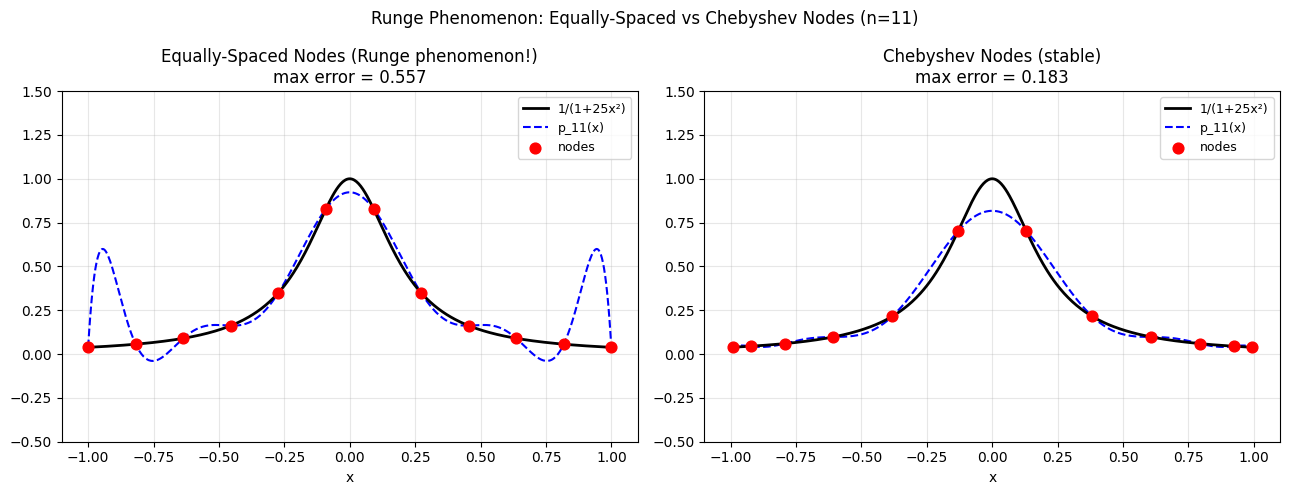

## 7. Error Analysis

### Interpolation Error Theorem

If $f$ has $n+1$ continuous derivatives on $[a, b]$ and $p_n$ is the interpolating polynomial at nodes $x_0, \ldots, x_n$, then for any $x \in [a, b]$:

$$f(x) - p_n(x) = \frac{f^{(n+1)}(\xi)}{(n+1)!} \prod_{i=0}^{n}(x - x_i)$$

for some $\xi \in (\min x_i, \max x_i)$.

### Practical bound

$$\|f - p_n\|_\infty \leq \frac{M_{n+1}}{(n+1)!} \|\omega_{n+1}\|_\infty$$

where $M_{n+1} = \max |f^{(n+1)}|$ and $\omega_{n+1}(x) = \prod_{i=0}^{n}(x - x_i)$.

### Key insight
- Error depends on both $f^{(n+1)}$ (smoothness) and the node spread
- Chebyshev nodes **minimize** $\|\omega_{n+1}\|_\infty$

In [8]:
# Numerical convergence study for f(x) = exp(x) on [0,1]
# Exact: f^(n+1) = exp(x), max ~ e^1 = 2.718
# Error ~ e / (n+1)!  *  h^(n+1)/4  for equispaced

f_test = math.exp
df_test = math.exp  # f and all derivatives equal exp

x_min, x_max = 0.0, 1.0
x_check = [x_min + (x_max-x_min)*i/99 for i in range(100)]

print("Convergence of polynomial interpolation for exp(x) on [0,1]")
print(f"{'n (degree)':>12} | {'Max Error':>14} | {'Ratio (prev/cur)':>18}")
print("-" * 50)

prev_err = None
for n in [2, 4, 6, 8, 10, 12, 14]:
    nodes_x = [x_min + (x_max-x_min)*i/n for i in range(n+1)]
    nodes_y = [f_test(xi) for xi in nodes_x]
    interp = NewtonInterpolation(nodes_x, nodes_y)
    
    max_err = max(abs(interp.evaluate(xi) - f_test(xi)) for xi in x_check)
    ratio = f"{prev_err/max_err:.1f}x" if prev_err is not None else "—"
    print(f"{n:12d} | {max_err:14.3e} | {ratio:>18}")
    prev_err = max_err

print("\nError decreases super-linearly — factorial convergence for analytic functions!")

Convergence of polynomial interpolation for exp(x) on [0,1]
  n (degree) |      Max Error |   Ratio (prev/cur)
--------------------------------------------------
           2 |      1.442e-02 |                  —
           4 |      5.262e-05 |             274.1x
           6 |      1.190e-07 |             442.2x
           8 |      1.750e-10 |             679.9x
          10 |      1.807e-13 |             968.2x
          12 |      1.998e-15 |              90.4x
          14 |      7.105e-15 |               0.3x

Error decreases super-linearly — factorial convergence for analytic functions!


## 8. Practical Application: Geophysical Data Interpolation

In geophysics, we often have measurement data at discrete stations and need to interpolate between them. Let's simulate a 1D seismic velocity profile interpolation.

In [10]:
import math, random
random.seed(42)

# Simulated velocity profile: stations at depth 0-5 km
# True velocity: v(z) = 2.0 + 0.8*z + 0.1*sin(2*pi*z/3)  [km/s]
def true_velocity(z):
    return 2.0 + 0.8*z + 0.1*math.sin(2*math.pi*z/3)

# Measurement stations (sparse)
station_depths = [0.0, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0]
station_vels = [true_velocity(z) + random.gauss(0, 0.01) for z in station_depths]

# Build interpolation
interp_newt = NewtonInterpolation(station_depths, station_vels)

# Dense evaluation for plot
z_fine = [i*0.02 for i in range(251)]    # 0 to 5 km, 1/50 km steps
v_true = [true_velocity(z) for z in z_fine]
v_interp = [interp_newt.evaluate(z) for z in z_fine]

max_err = max(abs(vi - vt) for vi, vt in zip(v_interp, v_true))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: velocity profile (depth on y-axis, geophysics convention)
ax1.plot(v_true, z_fine, 'k-', linewidth=2, label='True velocity')
ax1.plot(v_interp, z_fine, 'b--', linewidth=1.5, label='Interpolated')
ax1.scatter(station_vels, station_depths, color='red', zorder=5, s=80, label='Stations')
ax1.invert_yaxis()
ax1.set_xlabel('Velocity (km/s)')
ax1.set_ylabel('Depth (km)')
ax1.set_title('1D Velocity Profile\n(Newton Interpolation)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: interpolation error vs depth
err = [abs(vi - vt) for vi, vt in zip(v_interp, v_true)]
ax2.plot(err, z_fine, 'r-', linewidth=1.5)
ax2.invert_yaxis()
ax2.set_xlabel('|Error| (km/s)')
ax2.set_ylabel('Depth (km)')
ax2.set_title(f'Interpolation Error\nMax = {max_err:.4f} km/s')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(left=0)

plt.tight_layout()
plt.savefig('velocity_interpolation.png', dpi=100, bbox_inches='tight')
plt.close()

print(f"Max interpolation error: {max_err:.4f} km/s")
print("Station data has ~0.01 noise, interpolation still very accurate between stations.")

Max interpolation error: 0.0626 km/s
Station data has ~0.01 noise, interpolation still very accurate between stations.


## 9. Summary

| Concept | Key Point |
|---------|-----------|
| **Uniqueness** | Exactly one polynomial of degree $\leq n$ passes through $n+1$ distinct points |
| **Lagrange form** | Explicit basis polynomials $L_i(x)$; $O(n^2)$ per evaluation |
| **Newton form** | Divided differences; $O(n)$ update when adding new data |
| **Same polynomial** | Both forms represent the identical unique interpolant |
| **Runge phenomenon** | High-degree equispaced interpolation can oscillate wildly near edges |
| **Chebyshev nodes** | Optimal node placement that minimizes the interpolation error |
| **Error bound** | $\|f - p_n\|_\infty \leq \frac{M_{n+1}}{(n+1)!} \|\omega\|_\infty$ |

### Exercises
1. Use `NewtonInterpolation` to interpolate $\cos(x)$ at 5 equispaced nodes on $[0, \pi]$. What is the maximum error?
2. Repeat with 5 Chebyshev nodes. Compare the errors.
3. For the velocity profile example, experiment with 10 stations vs 5. How does error change?
4. Prove that the divided difference $f[x_0, \ldots, x_n]$ equals $f^{(n)}(\xi)/n!$ for some $\xi$ (hint: use the error formula).
5. Add a 4th-degree polynomial `PolyFit` (from Tutorial 8) to the velocity profile plot and compare with the interpolating polynomial. What is the fundamental difference?